In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score


In [30]:
def plot_fs(x):
    n = len(x)
    fft_vals = np.fft.rfft(x,n)
    psd = np.abs(fft_vals)**2
    freqs = np.fft.rfftfreq(n)
    plt.plot(freqs[1:n//10], psd[1:n//10])
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title("Fourier Spectrum")
    plt.show()

In [17]:
51//2

25

In [7]:
def MG_generate_interp(gamma=0.1,beta=0.2,tau=60,theta=1,n=10,x0=0.2,N=1000000,delta=0.01,interval=1):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)+0.1
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    x_delta = MG_rk4(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  return T,X

In [12]:
T,X = MG_generate_interp(N = 1200000)
T,X = T[::100],X[::100]

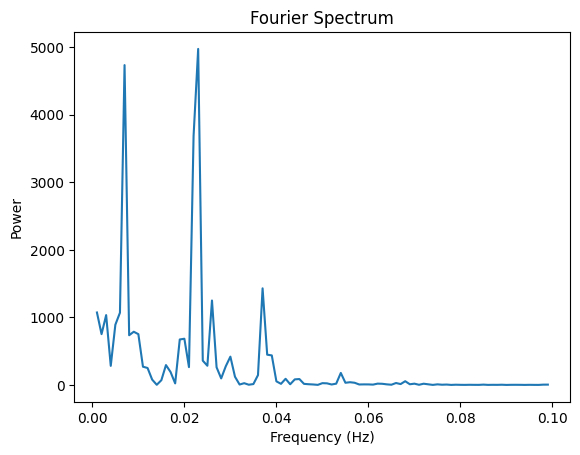

In [32]:
plot_fs(X[10000:11000])

In [38]:
def plot_ami_lag(x, max_lag=100, bins=64):
    # Discretize data into bins
    _, bin_edges = np.histogram(x, bins=bins)
    digitized = np.digitize(x, bin_edges[:-1])
    
    ami = []
    for lag in range(1, max_lag):
        x1 = digitized[:-lag]
        x2 = digitized[lag:]
        mi = mutual_info_score(x1, x2)
        ami.append(mi)

    plt.plot(range(1, max_lag), ami)
    plt.xlabel("Lag")
    plt.ylabel("AMI")
    plt.title("Average Mutual Information")
    plt.show()

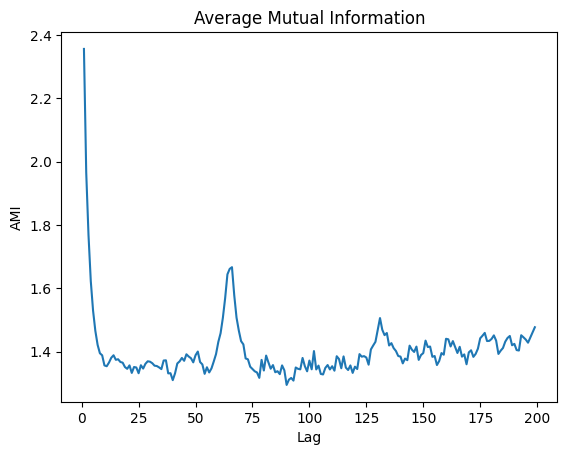

In [42]:
plot_ami_lag(X[10000:11000], max_lag=200, bins=64)